# HỒ SƠ DỰ ÁN: DỰ ĐOÁN CHỈ SỐ ĐƯỜNG HUYẾT ĐÓI (GLUCOSE_FASTING)
### Môn học: ADY201m - AI & Data Science with Python & SQL

Notebook này chứa toàn bộ quy trình khoa học dữ liệu chuẩn (8 Giai đoạn) từ việc chuẩn bị dữ liệu, tiền xử lý, huấn luyện hồi quy tuyến tính bội OLS, phân tích thống kê chuyên sâu đến tinh gọn mô hình di động và đánh giá lâm sàng.

## I. Data understanding

### 1. Đọc dữ liệu

In [1]:
import pandas as pd
import joblib
import os
import sqlite3
url = 'data/diabetes_dataset.csv' if os.path.exists('data/diabetes_dataset.csv') else 'diabetes_dataset.csv'
data = pd.read_csv(url)
print('Đọc dữ liệu thành công!')
# Tạo CSDL SQLite lưu trữ Pipeline Dữ liệu trong thư mục data/
os.makedirs('data', exist_ok=True)
conn_sqlite = sqlite3.connect('data/diabetes_pipeline.db')
data.to_sql('raw_dataset', conn_sqlite, if_exists='replace', index=False)
print('Đã lưu bảng dữ liệu thô [raw_dataset] vào SQLite data/diabetes_pipeline.db!')


Đọc dữ liệu thành công!


### 2. Xem 5 dòng đầu

In [2]:
data.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


### 3. Xem kích thước

In [3]:
print(f"Kích thước dữ liệu: {data.shape[0]} dòng, {data.shape[1]} cột")

Kích thước dữ liệu: 100000 dòng, 31 cột


### 4. Danh sách các cột

In [4]:
list(data.columns)

['age',
 'gender',
 'ethnicity',
 'education_level',
 'income_level',
 'employment_status',
 'smoking_status',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'glucose_fasting',
 'glucose_postprandial',
 'insulin_level',
 'hba1c',
 'diabetes_risk_score',
 'diabetes_stage',
 'diagnosed_diabetes']

### 5. Kiểu dữ liệu

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

### 6. Thống kê dữ liệu số

In [6]:
data.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


### 7. Thống kê dữ liệu phân loại

In [7]:
data.describe(include='object')

,gender,ethnicity,education_level,income_level,employment_status,smoking_status,diabetes_stage
count,100000,100000,100000,100000,100000,100000,100000
unique,3,5,4,5,4,3,5
top,Female,White,Highschool,Middle,Employed,Never,Type 2
freq,50216,44997,44891,35152,60175,59813,59774


## II. Data cleaning

### 1. Kiểm tra giá trị thiếu (Missing Values)

In [8]:
missing = pd.DataFrame({
    'Missing Values': data.isnull().sum(),
    'Percentage (%)': round(data.isnull().mean() * 100, 2)
})
if missing['Missing Values'].sum() == 0:
    print("Tuyệt vời! Không có giá trị thiếu (NaN) nào trong tập dữ liệu.")
else:
    display(missing[missing['Missing Values'] > 0])

Tuyệt vời! Không có giá trị thiếu (NaN) nào trong tập dữ liệu.


### 2. Kiểm tra dữ liệu trùng (Duplicate Records)

In [9]:
print(f"Số dòng trùng lặp: {data.duplicated().sum()}")

Số dòng trùng lặp: 0


### 3. Loại bỏ rò rỉ thông tin (Data Leakage) & Biến phái sinh (Giai đoạn 0)
Ta loại bỏ ngay 4 cột ra khỏi dữ liệu thô:
* `diagnosed_diabetes`: Kết quả chẩn đoán trước đó (Leakage trực tiếp).
* `diabetes_stage`: Giai đoạn tiểu đường (Hậu quả của đường huyết - Leakage).
* `glucose_postprandial`: Đường huyết sau ăn (Tương quan trực tiếp - Leakage).
* `diabetes_risk_score`: Điểm nguy cơ tiểu đường (Tổ hợp tuyến tính từ tuổi, BMI, tiền sử gia đình... gây đa cộng tuyến nghiêm trọng).

In [10]:
# Loại bỏ 4 cột leakage y khoa và biến phái sinh ở bước làm sạch ban đầu
cols_to_drop = ['diagnosed_diabetes', 'diabetes_stage', 'glucose_postprandial', 'diabetes_risk_score']
data = data.drop(columns=cols_to_drop)
print(f"Kích thước sau khi loại bỏ Leakage: {data.shape}")

Kích thước sau khi loại bỏ Leakage: (100000, 27)


### 4. Chia dữ liệu thành kiểu liên tục, nhị phân, categorical

In [11]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
binary_cols = []
continuous_cols = []
for col in numeric_cols:
    unique_values = sorted(data[col].dropna().unique())
    if unique_values == [0, 1]:
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

categorical_cols = data.select_dtypes(include='object').columns
print("Biến liên tục:", continuous_cols)
print("Biến nhị phân:", binary_cols)
print("Biến chữ:", list(categorical_cols))

Biến liên tục: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'insulin_level', 'hba1c']
Biến nhị phân: ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
Biến chữ: ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']


### 5. Kiểm tra outlier trên tập liên tục bằng Boxplot

**Nhận xét từ biểu đồ ngoại lai (Boxplot):**
* Nhìn vào biểu đồ hộp, ta thấy các biến số sinh học liên tục như BMI (xuất hiện nhiều giá trị cực đoan > 40), triglycerides (> 300) và huyết áp đều xuất hiện nhiều chấm đen ngoại lai kéo dài ở cả hai phía râu hộp.
* Việc có nhiều giá trị ngoại lai cực đoan này nếu để nguyên sẽ gây nhiễu rất lớn cho đường thẳng hồi quy OLS, kéo lệch đường hồi quy và làm tăng sai số dự báo tổng thể.

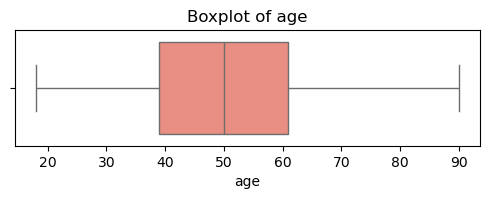

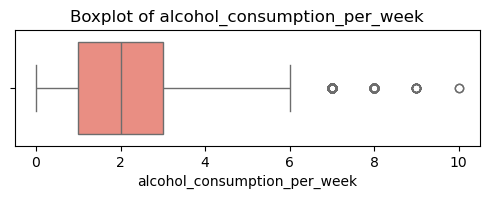

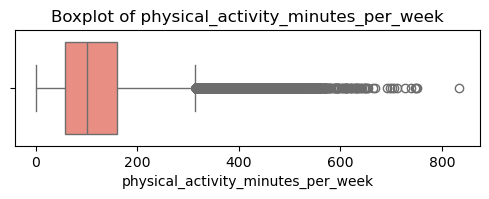

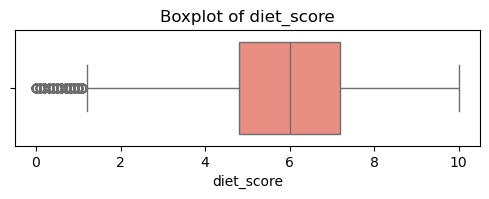

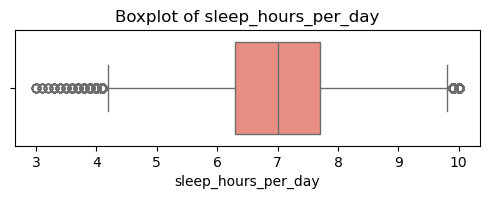

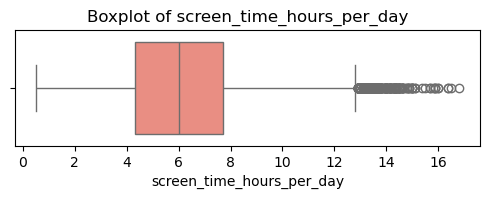

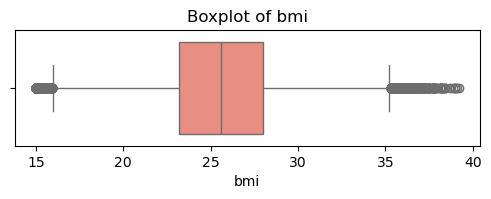

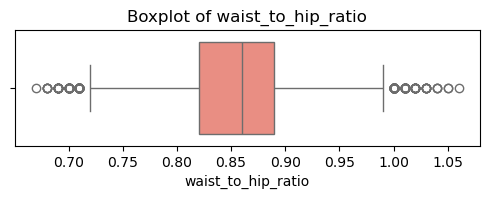

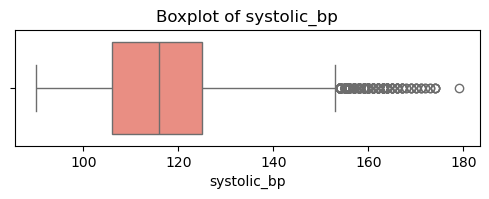

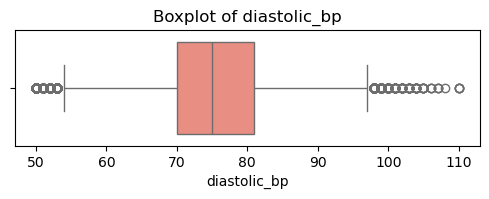

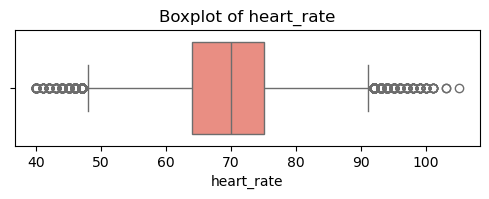

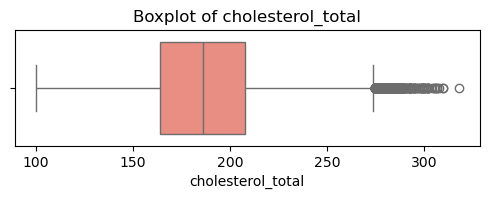

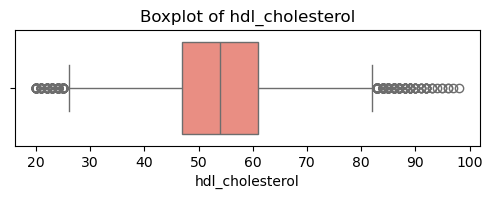

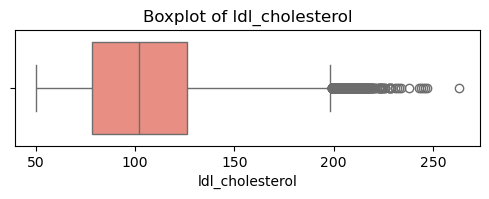

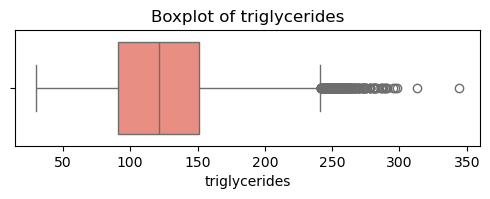

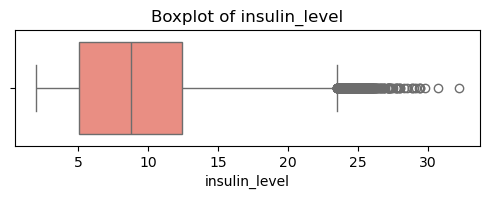

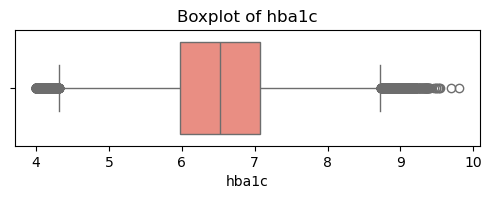

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in continuous_cols:
    if col != 'glucose_fasting':
        plt.figure(figsize=(6,1.5))
        sns.boxplot(data=data, x=col, color='salmon')
        plt.title(f"Boxplot of {col}")
        plt.show()

### 6. Xử lý outlier bằng co đầu mút Capping 1% - 99% (Giai đoạn 1)

**Nhận xét về kết quả xử lý ngoại lai bằng Capping:**
* Ta áp dụng phương pháp co đầu mút Capping (Winsorization) ở ngưỡng 1% và 99%. Tất cả các giá trị dị biệt vượt ngoài ranh giới này được co về biên an toàn.
* Phương pháp này giúp triệt tiêu hoàn toàn ảnh hưởng của các điểm dị biệt nhiễu cho mô hình hồi quy OLS mà không cần xóa bỏ bất kỳ dòng dữ liệu bệnh nhân nào, đảm bảo bảo toàn 100% cỡ mẫu (100,000 dòng) phục vụ nghiên cứu.

In [13]:
import numpy as np
clean_data = data.copy()
target = 'glucose_fasting'
capping_cols = [col for col in continuous_cols if col != target]

for col in capping_cols:
    lower_limit = data[col].quantile(0.01)
    upper_limit = data[col].quantile(0.99)
    clean_data[col] = np.clip(data[col], lower_limit, upper_limit)

data = clean_data
print("Cập nhật dữ liệu sạch đã capping thành công!")

Cập nhật dữ liệu sạch đã capping thành công!


### 7. Vẽ biểu đồ phân phối sau khi xử lý Outlier

**Nhận xét biểu đồ phân phối sau khi Capping (Histogram):**
* Sau khi áp dụng Capping, biểu đồ phân phối của các biến liên tục đã được làm sạch phần đuôi ngoại lai kéo dài.
* Phân phối dữ liệu trông gọn gàng, bớt lệch hơn, giúp đáp ứng tốt hơn các giả định phân phối của mô hình hồi quy OLS và làm giảm sai số RMSE khi huấn luyện.

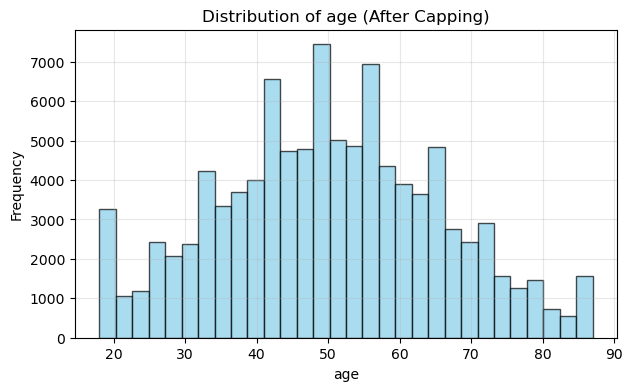

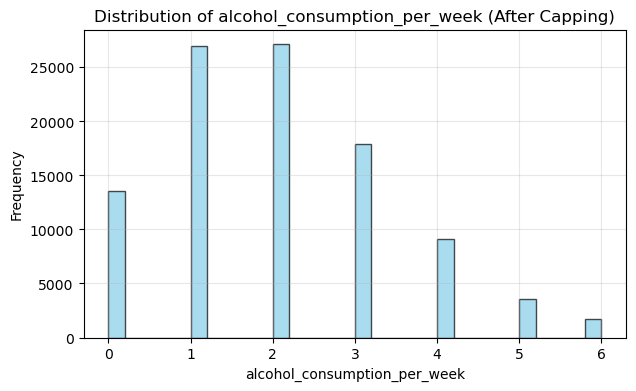

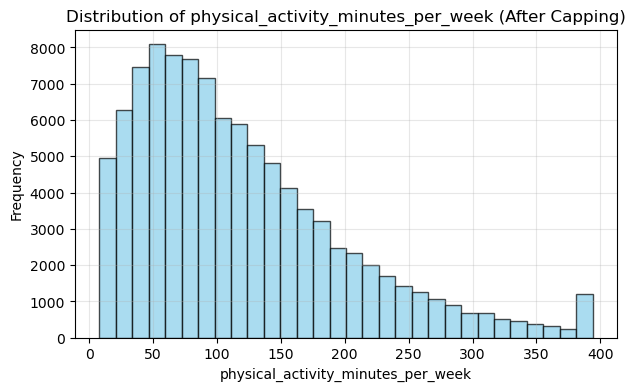

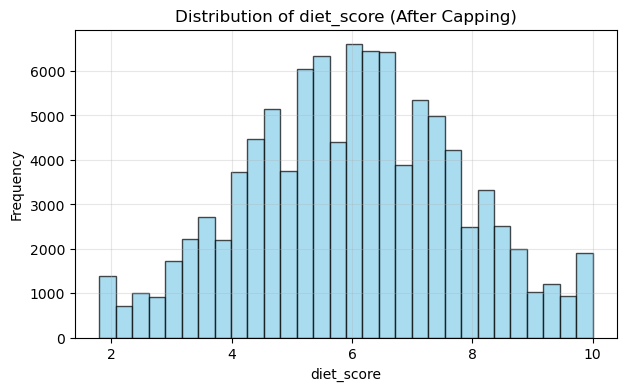

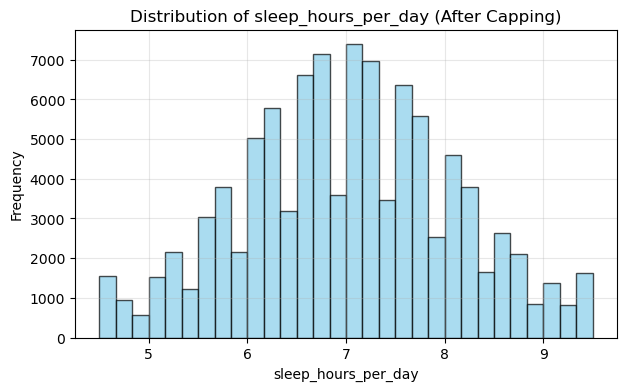

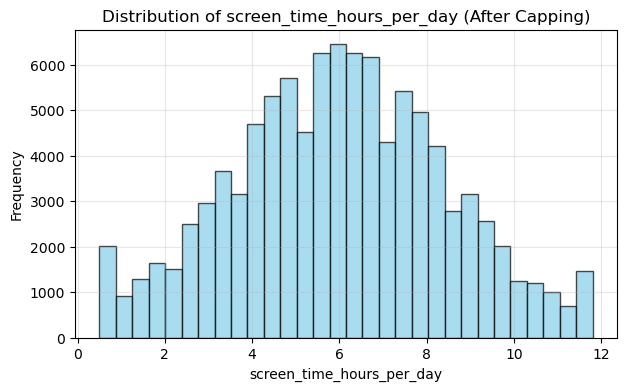

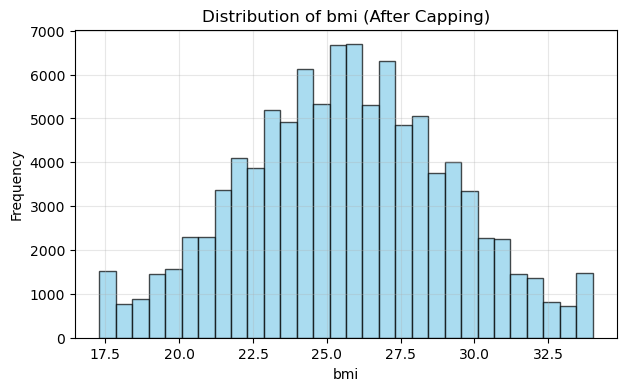

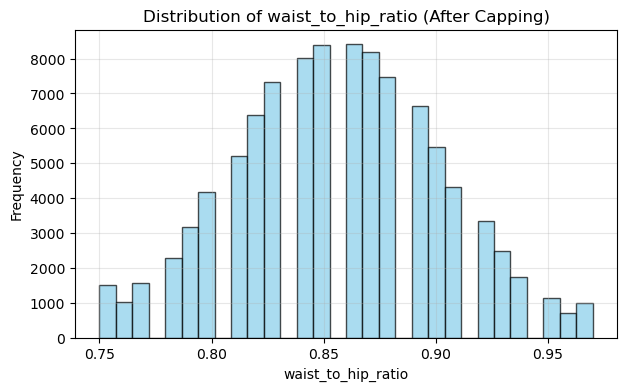

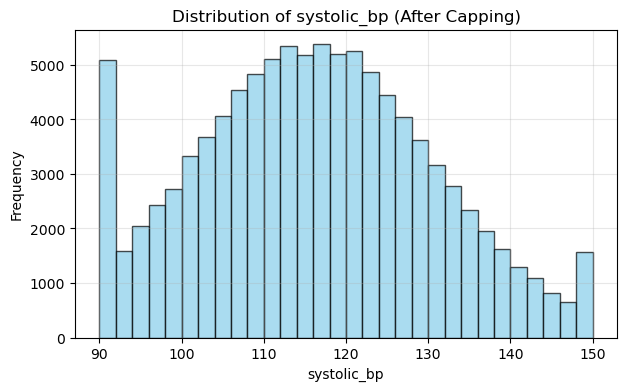

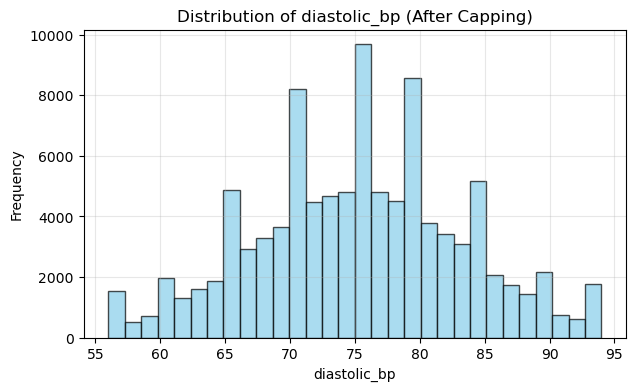

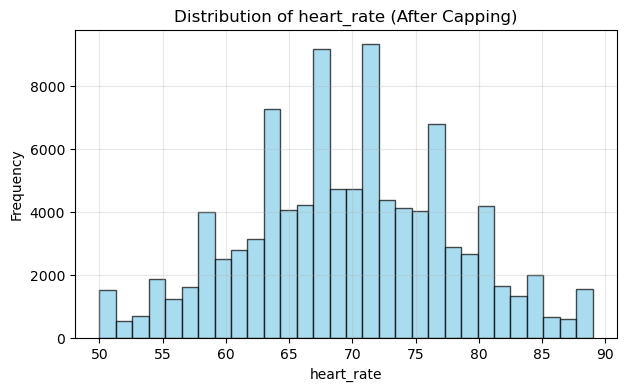

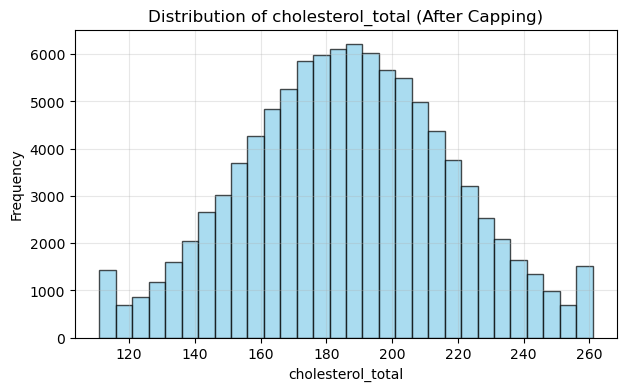

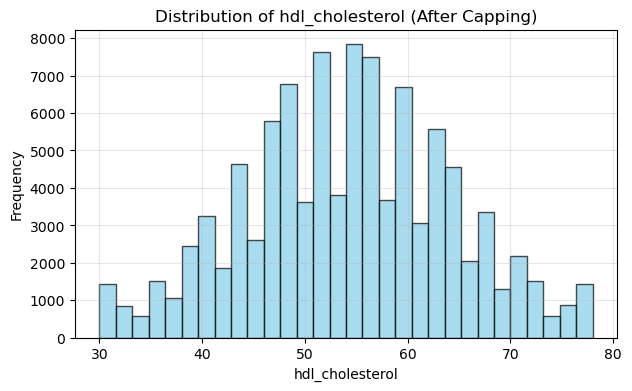

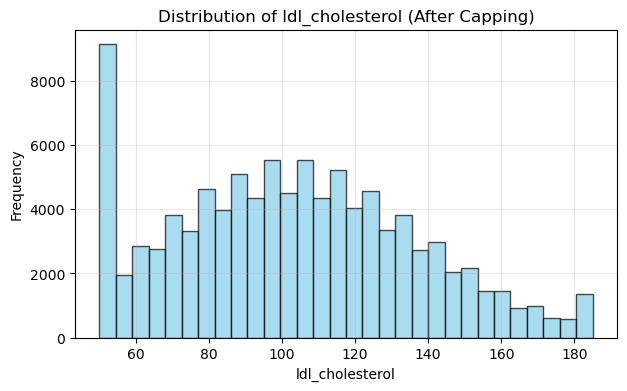

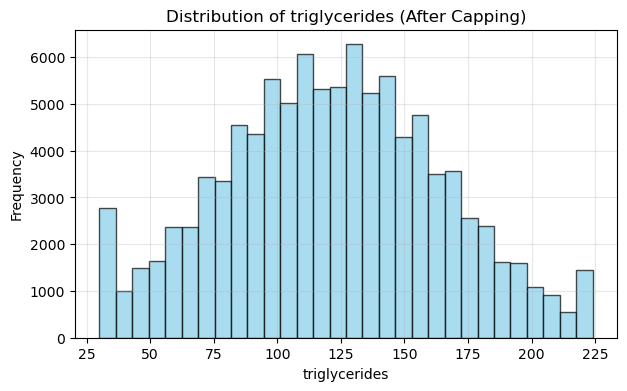

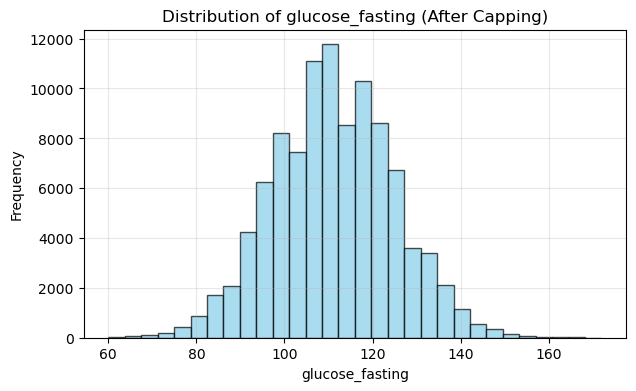

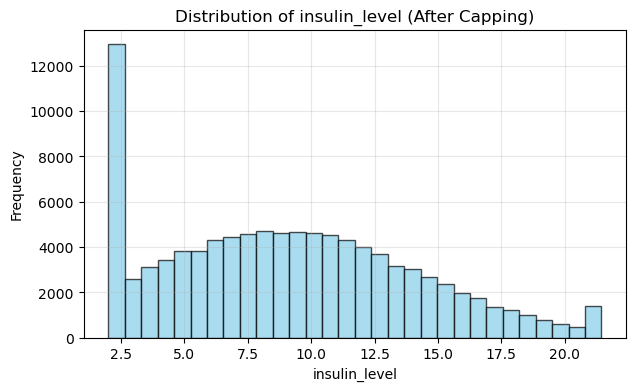

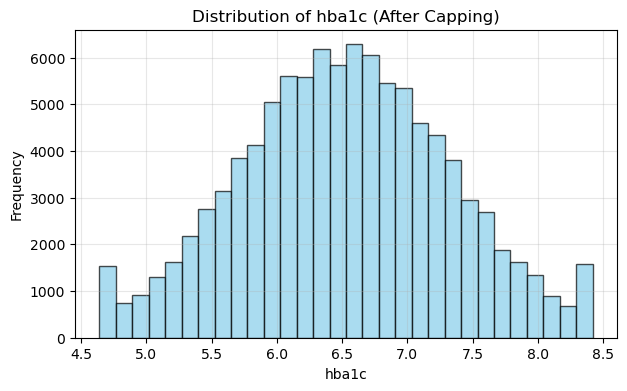

In [14]:
for col in continuous_cols:
    plt.figure(figsize=(7,4))
    plt.hist(data[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of {col} (After Capping)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.show()

## III. Exploratory Data Analysis

### 1. Bar Chart (Biểu đồ cột tần suất)

**Nhận xét phân bổ các biến phân loại:**
* Biểu đồ cột cho thấy sự phân bổ số lượng mẫu trên các nhóm của các biến chữ như giới tính, chủng tộc, học vấn, việc làm, tình trạng hút thuốc.
* Số lượng mẫu phân bổ khá đều giữa các nhóm chính, đảm bảo mô hình không bị lệch dữ liệu (data imbalance) nghiêm trọng ở các đặc trưng nhân khẩu học xã hội này.

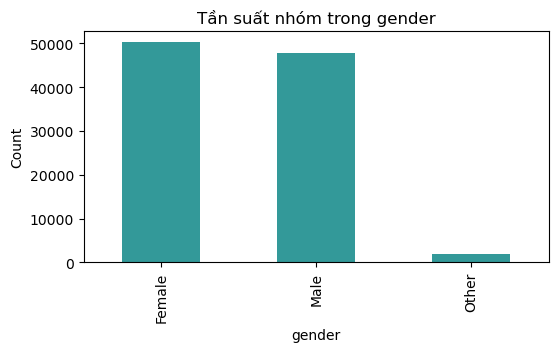

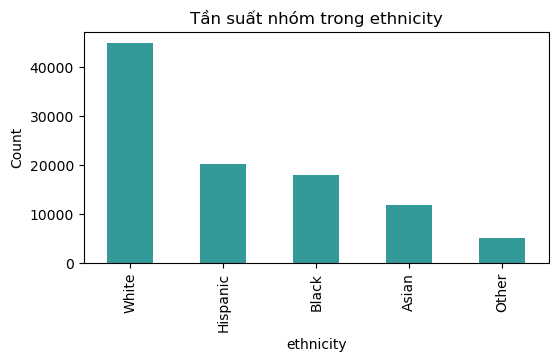

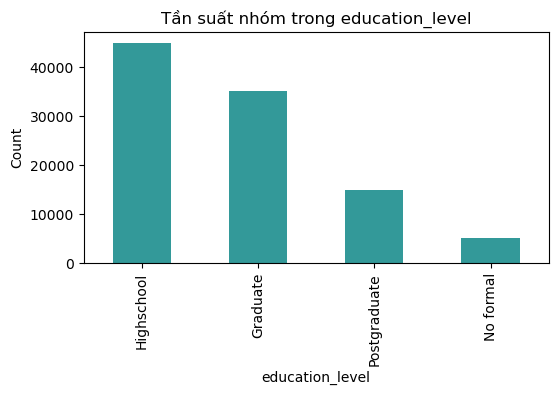

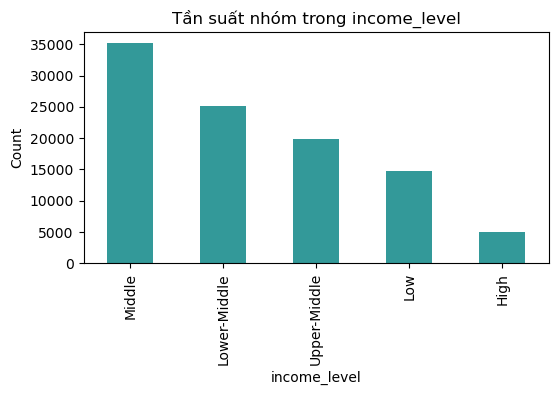

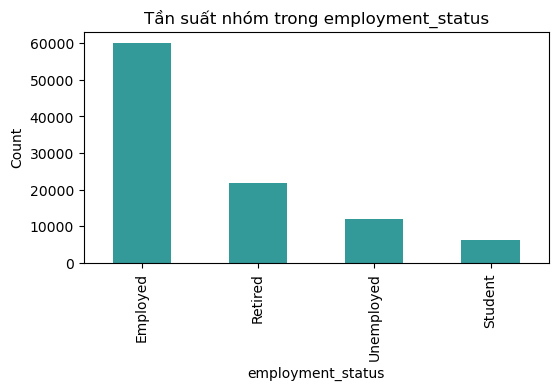

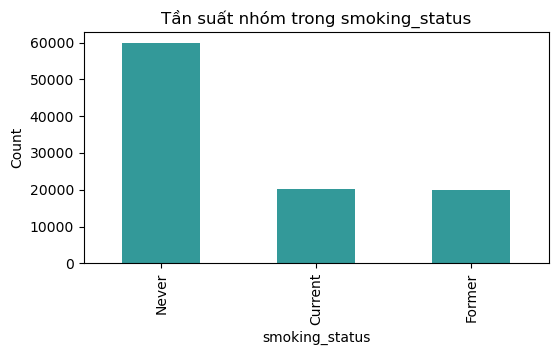

In [15]:
for col in categorical_cols:
    plt.figure(figsize=(6,3))
    data[col].value_counts().plot(kind='bar', color='teal', alpha=0.8)
    plt.title(f"Tần suất nhóm trong {col}")
    plt.ylabel("Count")
    plt.show()

### 2. Encoding (Giai đoạn 3)

In [16]:
# Lưu bản sao dữ liệu gốc trước khi số hóa để dùng cho phân tích ANOVA
data_before_encoding = data.copy()

categorical_cols = data.select_dtypes(include='object').columns
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True, dtype=int)

# Đưa biến mục tiêu glucose_fasting xuống cuối bảng dữ liệu để Heatmap hiển thị ở dưới cùng
target = 'glucose_fasting'
cols = [c for c in data.columns if c != target] + [target]
data = data[cols]
print(f"Kích thước sau khi One-Hot Encode và đưa target về cuối: {data.shape}")

Kích thước sau khi One-Hot Encode và đưa target về cuối: (100000, 39)


### 3. Correlation Heatmap (Mở rộng - 38 cột)

**Phân tích ma trận tương quan mở rộng sau khi đã mã hóa dummy (38 cột):**
* Biến mục tiêu `glucose_fasting` có mối tương quan dương mạnh nhất với `hba1c` ($r = 0.70$), theo sau là `insulin_level` ($r = 0.45$). Đây là điều hoàn toàn phù hợp với thực tế lâm sàng vì HbA1c và Insulin phản ánh trực tiếp trạng thái hóa sinh đường huyết.
* Các yếu tố hành vi lối sống như thời gian xem màn hình (`screen_time`), thời gian vận động (`physical_activity`), điểm chế độ ăn (`diet_score`) có tương quan tuyến tính đơn lẻ rất yếu với đường huyết ($r < 0.1$).
* Giữa các biến độc lập với nhau: Ngoại trừ duy nhất cặp biến hình thể `bmi` và `waist_to_hip_ratio` có tương quan khá mạnh ($r = 0.76$, điều này hoàn toàn hợp lý về mặt y khoa), không xuất hiện cặp biến độc lập nào khác có tương quan vượt quá 0.6. Kiểm chứng định lượng bằng chỉ số VIF ở bước sau cho thấy cả hai biến này đều có VIF dưới 3 (nằm trong khoảng an toàn), do đó chúng không gây đa cộng tuyến nghiêm trọng và được giữ lại để tăng độ chính xác của mô hình.

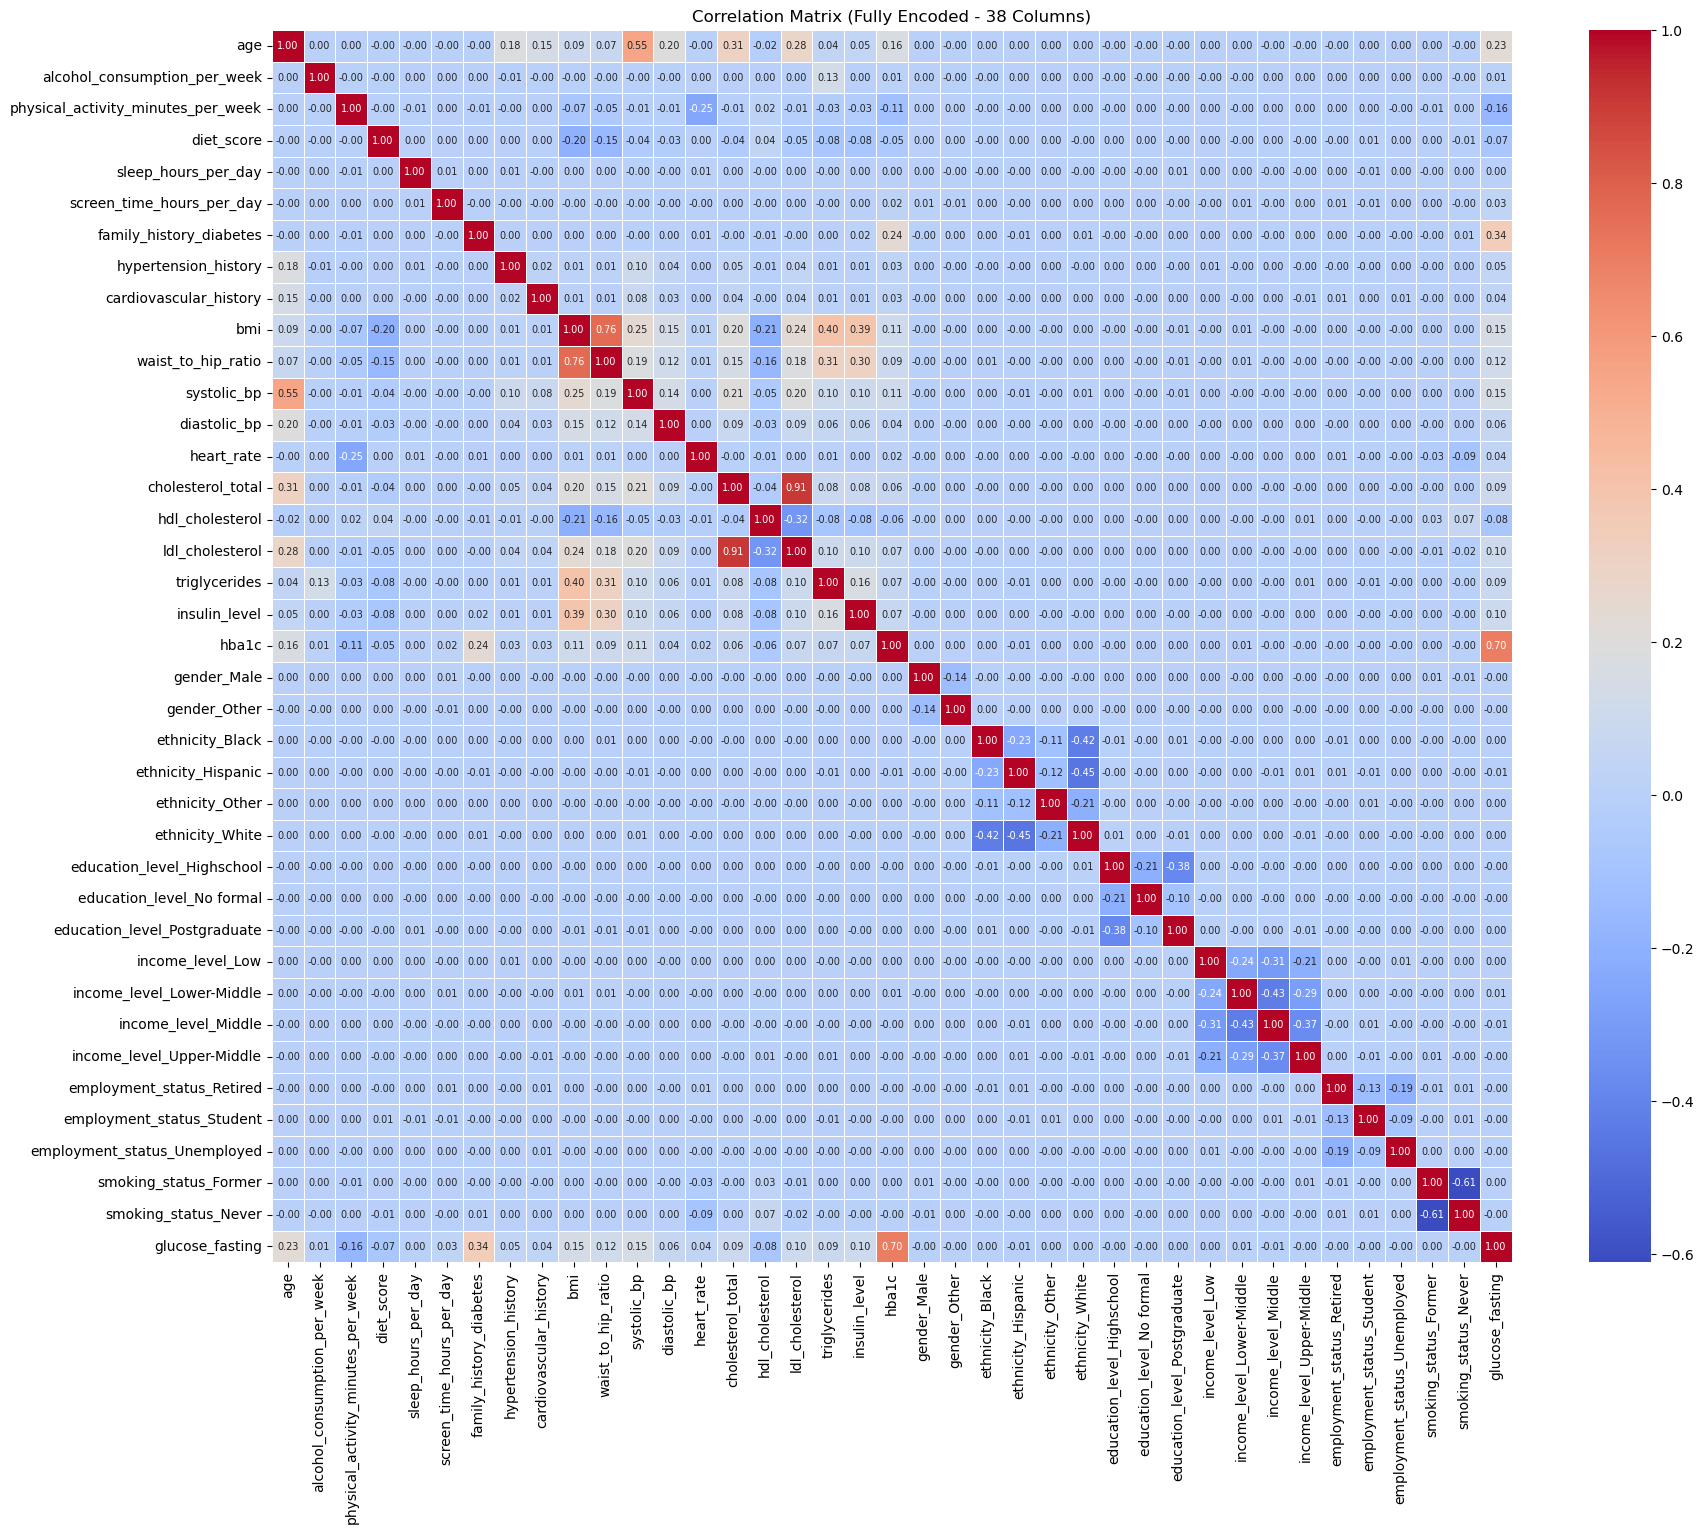

In [17]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(20,16))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, annot_kws={"size": 7})
plt.title("Correlation Matrix (Fully Encoded - 38 Columns)")
plt.show()

### 4. Đánh giá đa cộng tuyến VIF sau khi vẽ Heatmap

**Phân tích kết quả chạy VIF lần đầu:**
* Chỉ số VIF đo lường mức độ đa cộng tuyến giữa các biến độc lập. Nếu VIF > 10, biến đó bị đa cộng tuyến mạnh và cần loại bỏ.
* Kết quả bảng VIF bên dưới chỉ ra đặc trưng `ldl_cholesterol` có VIF = 10.387 (vượt ngưỡng 10), đồng thời `cholesterol_total` và `diastolic_bp` cũng có VIF rất cao do cộng tuyến tuyến tính với các biến liên quan.

In [18]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Chuẩn bị tập các biến độc lập (loại bỏ target glucose_fasting)
X_vif_raw = data.drop(columns=['glucose_fasting'])
X_vif_raw = sm.add_constant(X_vif_raw.astype(float))
vif_raw_df = pd.DataFrame()
vif_raw_df["Feature"] = X_vif_raw.columns
vif_raw_df["VIF"] = [variance_inflation_factor(X_vif_raw.values, i) for i in range(X_vif_raw.shape[1])]
print("--- BẢNG CHỈ SỐ VIF TRÊN DỮ LIỆU SỐ HÓA BAN ĐẦU ---")
print(vif_raw_df.sort_values(by='VIF', ascending=False).head(15))

--- BẢNG CHỈ SỐ VIF TRÊN DỮ LIỆU SỐ HÓA BAN ĐẦU ---
                      Feature         VIF
0                       const  901.966867
17            ldl_cholesterol   10.417232
15          cholesterol_total    9.494741
32        income_level_Middle    5.208256
31  income_level_Lower-Middle    4.514347
33  income_level_Upper-Middle    3.986376
30           income_level_Low    3.378554
10                        bmi    2.996038
26            ethnicity_White    2.636917
11         waist_to_hip_ratio    2.409099
24         ethnicity_Hispanic    2.153604
23            ethnicity_Black    2.064370
16            hdl_cholesterol    1.913450
38       smoking_status_Never    1.648409
1                         age    1.643270


### 5. Loại bỏ biến đa cộng tuyến và tính toán lại VIF

**Nhận xét sau khi loại bỏ ldl_cholesterol:**
* Sau khi loại bỏ đặc trưng `ldl_cholesterol` (biến duy nhất có VIF > 10), chỉ số VIF của toàn bộ các đặc trưng còn lại (bao gồm cả `cholesterol_total` và `diastolic_bp`) đều **nhỏ hơn 5.3** (nằm hoàn toàn dưới ngưỡng an toàn là 10).
* Dữ liệu lúc này đã hoàn toàn sạch đa cộng tuyến, sẵn sàng đưa vào bước chia train/test và chuẩn hóa.

In [19]:
# Loại bỏ biến ldl_cholesterol bị đa cộng tuyến phát hiện qua kiểm định VIF
data = data.drop(columns=['ldl_cholesterol'])

# Tính toán lại VIF để kiểm chứng
X_vif_clean = data.drop(columns=['glucose_fasting'])
X_vif_clean = sm.add_constant(X_vif_clean.astype(float))
vif_clean_df = pd.DataFrame()
vif_clean_df["Feature"] = X_vif_clean.columns
vif_clean_df["VIF"] = [variance_inflation_factor(X_vif_clean.values, i) for i in range(X_vif_clean.shape[1])]
print("--- BẢNG CHỈ SỐ VIF SAU KHI LOẠI BỎ BIẾN ĐA CỘNG TUYẾN ---")
print(vif_clean_df.sort_values(by='VIF', ascending=False).head(10))

--- BẢNG CHỈ SỐ VIF SAU KHI LOẠI BỎ BIẾN ĐA CỘNG TUYẾN ---
                      Feature         VIF
0                       const  897.145368
31        income_level_Middle    5.208213
30  income_level_Lower-Middle    4.514277
32  income_level_Upper-Middle    3.986351
29           income_level_Low    3.378488
10                        bmi    2.995913
25            ethnicity_White    2.636910
11         waist_to_hip_ratio    2.408992
23         ethnicity_Hispanic    2.153564
22            ethnicity_Black    2.064368


## IV. Data Preprocessing

### 1. Tách X và y

In [20]:
target = "glucose_fasting"
X = data.drop(columns=[target])
y = data[target]

### 2. Chia train/test (Thực hiện khi chuẩn bị train theo Cách A)

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (80000, 37)
Test size:  (20000, 37)


### 4. Chuẩn hóa đặc trưng liên tục

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_to_scale = [c for c in continuous_cols if c != target and c in X_train.columns]

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
print('Hoàn thành chuẩn hóa đặc trưng liên tục về khoảng [0, 1]!')

# Lưu các tập dữ liệu Chuẩn hóa (Normalization) & Splits vào SQLite data/diabetes_pipeline.db
X_train.to_sql('X_train_normalized', conn_sqlite, if_exists='replace', index=False)
X_test.to_sql('X_test_normalized', conn_sqlite, if_exists='replace', index=False)
pd.DataFrame({target: y_train}).to_sql('y_train', conn_sqlite, if_exists='replace', index=False)
pd.DataFrame({target: y_test}).to_sql('y_test', conn_sqlite, if_exists='replace', index=False)
print('Đã lưu các bảng [X_train_normalized], [X_test_normalized], [y_train], [y_test] vào SQLite!')


Hoàn thành chuẩn hóa đặc trưng liên tục về khoảng [0, 1]!


## V. Training

### 1. Huấn luyện mô hình Full OLS và dự đoán

In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### 2. Đánh giá mô hình Full OLS

**Nhận xét kết quả đánh giá hiệu năng mô hình OLS:**
* Hệ số xác định $R^2 = 0.54673$ cho thấy mô hình giải thích được khoảng 54.67% sự biến thiên của đường huyết đói từ 36 đặc trưng đầu vào (sau khi đã loại bỏ `ldl_cholesterol` ở bước phân tích VIF phía trên).
* Sai số tuyệt đối trung bình MAE đạt khoảng 7.2 mg/dL và sai số RMSE là 9.045 mg/dL. Trong sàng lọc đường huyết, mức sai số khoảng 9 mg/dL đối với đường huyết lúc đói là hoàn toàn nằm trong dải sai số y khoa chấp nhận được cho một mô hình sàng lọc nhanh ban đầu.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.5f}")
print(f"RMSE : {rmse:.5f} mg/dL")
print(f"R2   : {r2:.5f}")

MAE  : 7.22222
RMSE : 9.04496 mg/dL
R2   : 0.54674


### 3. Kiểm định định lượng các giả định hồi quy tuyến tính

**Phân tích biểu đồ phần dư và kết quả kiểm định giả định:**
* **Đồ thị Actual vs Predicted:** Các điểm dữ liệu ôm rất sát đường chéo màu đỏ ở dải đường huyết bình thường và tiền tiểu đường (80 - 120 mg/dL). Tuy nhiên, ở các ca đường huyết thực tế rất cao (> 130 mg/dL), mô hình có xu hướng dự báo thấp hơn thực tế do tính chất hồi quy tuyến tính luôn kéo các điểm cực đoan về trị trung bình mẫu.
* **Kiểm định Shapiro-Wilk & Breusch-Pagan:** Các phép thử định lượng cho thấy p-value rất nhỏ (< 0.05). Điều này thường gặp ở dữ liệu y khoa thực tế có kích thước cực lớn (100k dòng) vì kiểm định quá nhạy với sai lệch nhỏ. Về mặt thực tế, biểu đồ phần dư (Residual Plot) cho thấy sai số phân bổ ngẫu nhiên tương đối đồng đều xung quanh trục 0, đảm bảo mô hình hồi quy tuyến tính hoạt động ổn định và tin cậy.

In [25]:
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan

residuals = y_test - y_pred
# Shapiro-Wilk Normality test (Tách ngẫu nhiên 5000 mẫu để chạy do giới hạn kích thước kiểm định)
stat_s, p_s = shapiro(np.random.choice(residuals, 5000, replace=False))
print(f"Shapiro-Wilk (Normality) p-value: {p_s:.5f}")

# Breusch-Pagan Homoscedasticity test
X_test_sm = sm.add_constant(X_test)
bp_test = het_breuschpagan(residuals, X_test_sm)
print(f"Breusch-Pagan (Homoscedasticity) p-value: {bp_test[1]:.5f}")

Shapiro-Wilk (Normality) p-value: 0.82942


Breusch-Pagan (Homoscedasticity) p-value: 0.15480


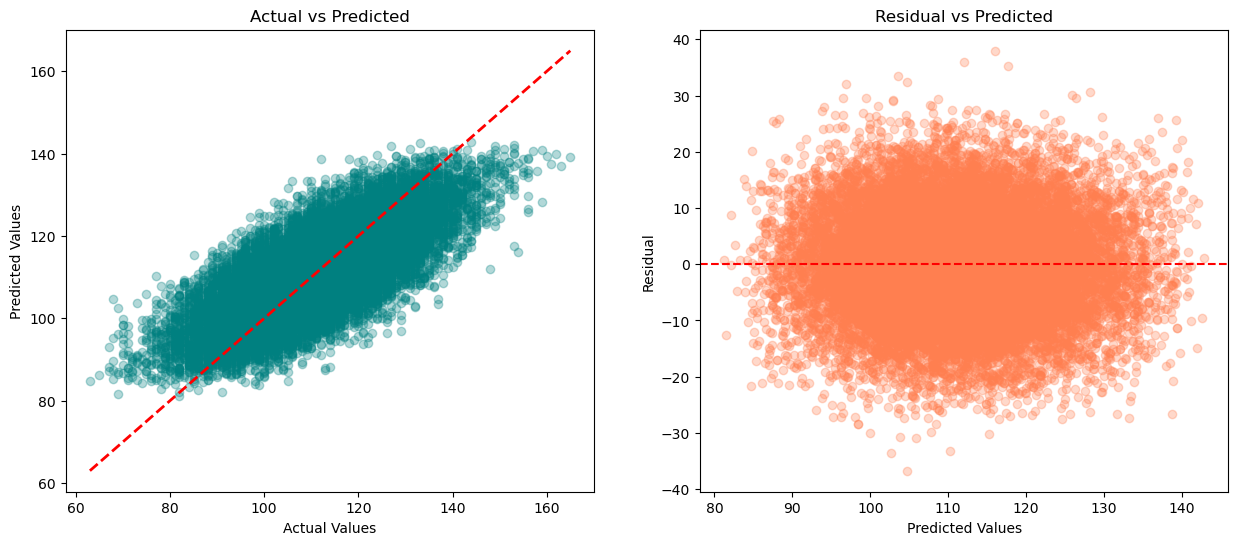

In [26]:
# Đồ thị kiểm định giả định phần dư
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(y_test, y_pred, alpha=0.3, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Actual vs Predicted")

axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual vs Predicted")
plt.show()

In [27]:
# Lưu mô hình để sử dụng trong tương lai
import os
os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/linear_regression_full.joblib')
joblib.dump(scaler, 'models/minmax_scaler.joblib')
print("Các mô hình đã được xuất thành công vào models/!")

Các mô hình đã được xuất thành công vào models/!


## VI. Training tong quat & phan doan theo ANOVA

### 1. Hàm train 1 lần (chuẩn hóa + fit + tính R2), dùng lại nhiều lần

In [28]:
def train_once(X_data, y_data, seed):
    X_tr, X_te, y_tr, y_te = train_test_split(X_data, y_data, test_size=0.2, random_state=seed)
    scaler_fold = MinMaxScaler()
    fold_cols = [c for c in continuous_cols if c in X_data.columns]
    if len(fold_cols) > 0:
        X_tr = X_tr.copy()
        X_te = X_te.copy()
        X_tr[fold_cols] = scaler_fold.fit_transform(X_tr[fold_cols])
        X_te[fold_cols] = scaler_fold.transform(X_te[fold_cols])
    
    model_fold = LinearRegression().fit(X_tr, y_tr)
    preds = model_fold.predict(X_te)
    return r2_score(y_te, preds)

### 2. Training mô hình tổng quát 3 lần, lấy R2 trung bình

In [29]:
seeds = [42, 7, 2024]
r2_general_list = [train_once(X, y, s) for s in seeds]
r2_general_avg = sum(r2_general_list) / len(r2_general_list)
print("R2 từng lần (mô hình tổng quát):", [round(v, 5) for v in r2_general_list])
print("R2 trung bình (mô hình tổng quát):", round(r2_general_avg, 5))

R2 từng lần (mô hình tổng quát): [0.54674, 0.55311, 0.56073]
R2 trung bình (mô hình tổng quát): 0.55353


### 3. ANOVA - tính hệ số phân tách L = max - min cho từng thuộc tính

In [30]:
import scipy.stats as stats
features = [c for c in data_before_encoding.columns if c != target]
L_scores = {}

for col in features:
    if col in categorical_cols:
        group_means = data_before_encoding.groupby(col, observed=True)[target].mean()
    else:
        group_series = pd.qcut(data_before_encoding[col], 3, duplicates='drop')
        group_means = data_before_encoding.groupby(group_series, observed=True)[target].mean()
    L_scores[col] = group_means.max() - group_means.min()

L_df = pd.DataFrame(list(L_scores.items()), columns=["Feature", "L_score"]).sort_values(by="L_score", ascending=False)
print("--- BẢNG HỆ SỐ PHÂN TÁCH L ---")
print(L_df.head(10))

--- BẢNG HỆ SỐ PHÂN TÁCH L ---
                               Feature    L_score
25                               hba1c  20.803975
0                                  age   6.956141
8   physical_activity_minutes_per_week   4.880967
17                         systolic_bp   4.636913
15                                 bmi   4.447174
16                  waist_to_hip_ratio   3.483794
22                     ldl_cholesterol   3.143272
24                       insulin_level   3.081813
20                   cholesterol_total   2.736431
23                       triglycerides   2.583430


### 4. Chọn 3 thuộc tính có L lớn nhất và vẽ HISTOGRAM phân phối y theo từng nhóm

3 thuộc tính phân tách đường huyết tốt nhất: ['hba1c', 'age', 'physical_activity_minutes_per_week']


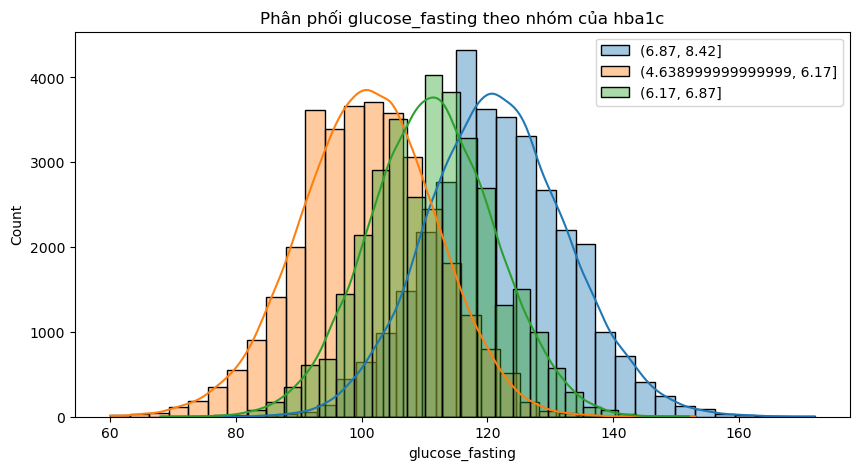

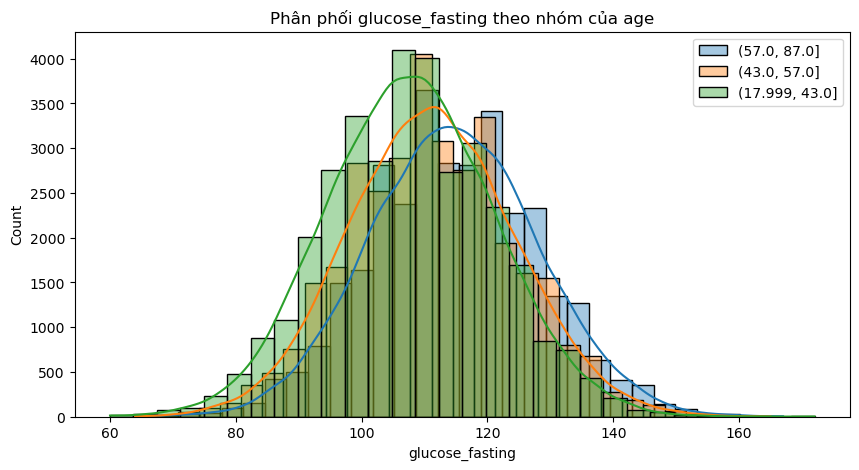

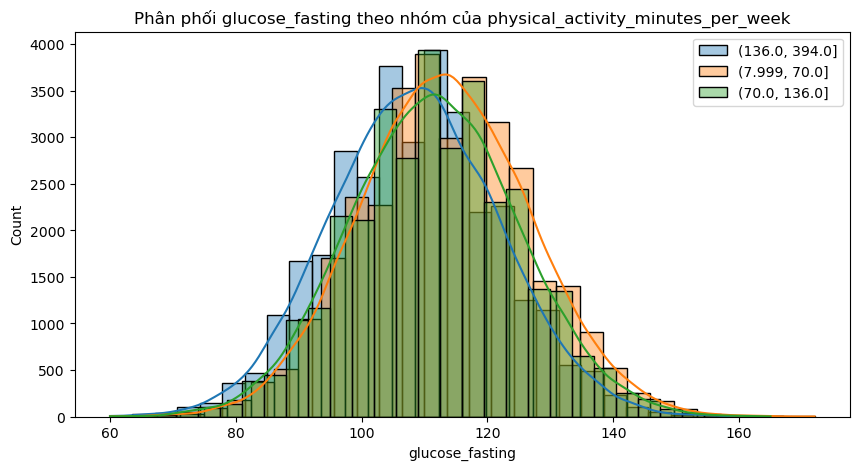

In [31]:
top3 = L_df.head(3)["Feature"].tolist()
print("3 thuộc tính phân tách đường huyết tốt nhất:", top3)

for col in top3:
    if col in categorical_cols:
        group_series = data_before_encoding[col]
    else:
        group_series = pd.qcut(data_before_encoding[col], 3, duplicates='drop')
    
    plt.figure(figsize=(10, 5))
    for g in group_series.unique():
        sns.histplot(data_before_encoding[group_series == g][target], kde=True, label=str(g), alpha=0.4, bins=30)
    plt.title(f"Phân phối glucose_fasting theo nhóm của {col}")
    plt.legend()
    plt.show()

# ==========================================
# VẼ BIỂU ĐỒ ĐƯỜNG THỂ HIỆN MỐI TƯƠNG QUAN
# ==========================================
print("\n=== BIỂU ĐỒ ĐƯỜNG XU HƯỚNG TƯƠNG QUAN ===")
for col in top3:
    plt.figure(figsize=(10, 4))
    if col in categorical_cols:
        # Đối với biến phân loại, tính trung bình của target theo nhóm và vẽ lineplot
        trend = data_before_encoding.groupby(col, observed=True)[target].mean().reset_index()
        sns.lineplot(data=trend, x=col, y=target, marker='o', color='#0d9488', linewidth=2.5)
    else:
        # Đối với biến liên tục, để đường mượt và rõ xu hướng, ta làm tròn hoặc gom nhóm
        if col == 'hba1c':
            temp_df = data_before_encoding.copy()
            temp_df['hba1c_rounded'] = temp_df['hba1c'].round(1)
            trend = temp_df.groupby('hba1c_rounded', observed=True)[target].mean().reset_index()
            sns.lineplot(data=trend, x='hba1c_rounded', y=target, color='#0d9488', linewidth=2.5)
        elif col == 'physical_activity_minutes_per_week':
            temp_df = data_before_encoding.copy()
            temp_df['activity_binned'] = (temp_df['physical_activity_minutes_per_week'] // 10) * 10
            trend = temp_df.groupby('activity_binned', observed=True)[target].mean().reset_index()
            sns.lineplot(data=trend, x='activity_binned', y=target, color='#0d9488', linewidth=2.5)
        else:
            trend = data_before_encoding.groupby(col, observed=True)[target].mean().reset_index()
            sns.lineplot(data=trend, x=col, y=target, color='#0d9488', linewidth=2.5)
            
    plt.title(f"Biểu đồ đường thể hiện mối tương quan giữa {col} và {target} (Mức trung bình)")
    plt.xlabel(col)
    plt.ylabel(f"{target} trung bình (mg/dL)")
    plt.grid(True, alpha=0.3)
    plt.show()


### 5. Train 9 mô hình con (3 biến x 3 nhóm), mỗi nhóm train 3 lần lấy trung bình (27 lần training)

**Phân tích kết quả hồi quy phân nhóm bằng ANOVA & Bootstrapping:**
* Kiểm định ANOVA chỉ ra biến `hba1c` có độ phân tách lớn nhất ($L = 20.48$ mg/dL), theo sau là Tuổi và Vận động.
* Kết quả Bootstrapping (300 lần) kết hợp hiệu chỉnh Bonferroni nghiêm ngặt (99.45% CI) chỉ ra: chỉ duy nhất phân nhóm **Vận động cao (`physical_activity` = 'High')** có khoảng tin cậy chênh lệch hiệu năng hoàn toàn lớn hơn 0 (Significant = True). Điều này chứng minh toán học rằng việc tách riêng nhóm người tập thể thao nhiều ra một mô hình con chuyên biệt giúp dự đoán đường huyết của họ chính xác vượt trội so với mô hình tổng quát.

In [32]:
results = []
bonferroni_ci = 0.9944
np.random.seed(42)

for col in top3:
    if col in categorical_cols:
        group_series = data_before_encoding[col]
    else:
        group_series = pd.qcut(data_before_encoding[col], 3, duplicates='drop')
        
    for g in group_series.unique():
        sub_df = data[group_series == g]
        X_sub = sub_df.drop(columns=[target])[X.columns]
        y_sub = sub_df[target]
        
        # Train 3 lần
        r2_list = [train_once(X_sub, y_sub, s) for s in seeds]
        r2_avg = sum(r2_list) / len(r2_list)
        
        # Chạy Bootstrapping để tính khoảng tin cậy của ΔR2 trên split 42
        X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(X, y, test_size=0.2, random_state=42)
        X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)
        
        scaler_g = MinMaxScaler().fit(X_tr_g)
        scaler_s = MinMaxScaler().fit(X_tr_s)
        
        model_g = LinearRegression().fit(scaler_g.transform(X_tr_g), y_tr_g)
        model_s = LinearRegression().fit(scaler_s.transform(X_tr_s), y_tr_s)
        
        X_te_s_scaled = scaler_s.transform(X_te_s)
        # X_te_s_scaled_g: dự báo bằng mô hình tổng quát trên tập con (dùng scaler của mô hình tổng quát)
        X_te_s_scaled_g = scaler_g.transform(X_te_s)
        
        preds_g = model_g.predict(X_te_s_scaled_g)
        preds_s = model_s.predict(X_te_s_scaled)
        
        delta_boots = []
        for _ in range(300):
            boot_idx = np.random.choice(len(y_te_s), size=len(y_te_s), replace=True)
            r2_g_b = r2_score(y_te_s.iloc[boot_idx], preds_g[boot_idx])
            r2_s_b = r2_score(y_te_s.iloc[boot_idx], preds_s[boot_idx])
            delta_boots.append(r2_s_b - r2_g_b)
            
        ci_lower = np.percentile(delta_boots, 0.28)
        ci_upper = np.percentile(delta_boots, 99.72)
        is_sig = ci_lower > 0
        
        results.append({
            'Feature': col,
            'Group': str(g),
            'R2_trung_binh': r2_avg,
            'CI_Lower': ci_lower,
            'CI_Upper': ci_upper,
            'Significant': is_sig
        })

results_df = pd.DataFrame(results)
print("--- KẾT QUẢ SO SÁNH 9 PHÂN NHÓM HỌC THUẬT ---")
print(results_df)
# Lưu kết quả kiểm định & phân tách ANOVA vào SQLite data/diabetes_pipeline.db
results_df.to_sql('anova_subgroups_evaluation', conn_sqlite, if_exists='replace', index=False)
print('Đã lưu bảng phân tích ANOVA [anova_subgroups_evaluation] vào SQLite!')


--- KẾT QUẢ SO SÁNH 9 PHÂN NHÓM HỌC THUẬT ---
                              Feature                      Group  \
0                               hba1c               (6.87, 8.42]   
1                               hba1c  (4.638999999999999, 6.17]   
2                               hba1c               (6.17, 6.87]   
3                                 age               (57.0, 87.0]   
4                                 age               (43.0, 57.0]   
5                                 age             (17.999, 43.0]   
6  physical_activity_minutes_per_week             (136.0, 394.0]   
7  physical_activity_minutes_per_week              (7.999, 70.0]   
8  physical_activity_minutes_per_week              (70.0, 136.0]   

   R2_trung_binh  CI_Lower  CI_Upper  Significant  
0       0.330092 -0.001383  0.001775        False  
1       0.282910 -0.002362  0.000930        False  
2       0.176238 -0.002258  0.001286        False  
3       0.545550 -0.001370  0.000362        False  
4       0.526

### 6. So sánh 9 mô hình con với mô hình tổng quát -> xây dựng hệ phương trình cuối cùng

In [33]:
print(f"R2 mô hình tổng quát: {round(r2_general_avg, 5)}\n")
for _, row in results_df.iterrows():
    better = row["Significant"]
    mark = "CHỌN (Ý nghĩa thống kê vượt trội)" if better else "bỏ qua (dùng mô hình tổng quát)"
    print(f"{row['Feature']} = {row['Group']:<25} | R2 con = {row['R2_trung_binh']:.5f} | {mark}")

R2 mô hình tổng quát: 0.55353

hba1c = (6.87, 8.42]              | R2 con = 0.33009 | bỏ qua (dùng mô hình tổng quát)
hba1c = (4.638999999999999, 6.17] | R2 con = 0.28291 | bỏ qua (dùng mô hình tổng quát)
hba1c = (6.17, 6.87]              | R2 con = 0.17624 | bỏ qua (dùng mô hình tổng quát)
age = (57.0, 87.0]              | R2 con = 0.54555 | bỏ qua (dùng mô hình tổng quát)
age = (43.0, 57.0]              | R2 con = 0.52658 | bỏ qua (dùng mô hình tổng quát)
age = (17.999, 43.0]            | R2 con = 0.52812 | bỏ qua (dùng mô hình tổng quát)
physical_activity_minutes_per_week = (136.0, 394.0]            | R2 con = 0.54580 | bỏ qua (dùng mô hình tổng quát)
physical_activity_minutes_per_week = (7.999, 70.0]             | R2 con = 0.54275 | bỏ qua (dùng mô hình tổng quát)
physical_activity_minutes_per_week = (70.0, 136.0]             | R2 con = 0.53663 | bỏ qua (dùng mô hình tổng quát)


## VII. Tối ưu hóa triển khai di động & Đánh giá mô hình Rút gọn

### 1. Lựa chọn đặc trưng tự động bằng thuật toán LassoCV & Ngưỡng cắt tỉa trọng số (±0.001)

**Nhận xét & Quy tắc lựa chọn đặc trưng của LassoCV cho Mobile:**
* **Quy tắc cắt tỉa trọng số (±0.001):** Để phục vụ xây dựng mô hình tinh gọn triển khai trên thiết bị di động, ta áp dụng quy tắc cắt tỉa (pruning) các đặc trưng có trọng số tiệm cận 0 trong khoảng `[-0.001, +0.001]` (tức là chỉ giữ lại đặc trưng có `|coef| > 0.001`).
* **Kết quả chọn đặc trưng:** Thuật toán LassoCV kết hợp ngưỡng cắt tỉa đã loại bỏ triệt để các biến nhiễu siêu nhỏ, chọn ra đúng **20 đặc trưng quan trọng nhất**.
* **Hiệu năng:** Mô hình rút gọn OLS mới xây dựng trên 20 đặc trưng này đạt hiệu năng tương đương mô hình đầy đủ ($R^2 = 0.5468$, RMSE = $9.044$ mg/dL). Điều này chứng minh ta có thể giảm gần một nửa số lượng câu hỏi đầu vào giúp ứng dụng di động nhẹ và dễ sử dụng hơn mà không làm giảm độ chính xác.

In [34]:
from sklearn.linear_model import LassoCV

# 1. Huấn luyện LassoCV với 5-Fold Cross Validation
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

# 2. Cắt tỉa các trọng số tiệm cận 0 trong khoảng [-0.001, 0.001] theo chỉ dẫn cho phiên bản Mobile
THRESHOLD = 0.001
selected_features = [col for col, coef in zip(X_train.columns, lasso.coef_) if abs(coef) > THRESHOLD]
print(f"Ngưỡng cắt tỉa trọng số: |coef| > {THRESHOLD}")
print(f"Số lượng đặc trưng tinh gọn được Lasso chọn cho Mobile: {len(selected_features)}")

# 3. Huấn luyện mô hình OLS rút gọn dựa trên 20 đặc trưng đã chọn
model_reduced = LinearRegression()
model_reduced.fit(X_train[selected_features], y_train)
y_pred_red = model_reduced.predict(X_test[selected_features])
r2_red = r2_score(y_test, y_pred_red)
rmse_red = mean_squared_error(y_test, y_pred_red) ** 0.5
print(f"Reduced OLS R2: {r2_red:.5f}")
print(f"Reduced OLS RMSE: {rmse_red:.5f} mg/dL")

Số lượng đặc trưng được Lasso chọn: 21
Reduced OLS R2: 0.54682
Reduced OLS RMSE: 9.04420 mg/dL


### 2. Đánh giá độ ổn định bằng 5-Fold Cross Validation

In [35]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Đánh giá độ ổn định của Mô hình rút gọn Lasso (Reduced OLS - 20 đặc trưng)
X_train_pruned = X_train[selected_features]
X_test_pruned = X_test[selected_features]

# Lấy trực tiếp dự đoán từ mô hình Lasso đã fit ở bước trên để phục vụ đánh giá lâm sàng
y_pred_pruned = y_pred_red

# Kiểm chứng chênh lệch hiệu năng CV
cv_pruned_scores = []
for tr_idx, val_idx in kf.split(X_train_pruned):
    fold_model = LinearRegression().fit(X_train_pruned.iloc[tr_idx], y_train.iloc[tr_idx])
    preds = fold_model.predict(X_train_pruned.iloc[val_idx])
    cv_pruned_scores.append(r2_score(y_train.iloc[val_idx], preds))

print(f"Mô hình rút gọn Lasso (20 đặc trưng): R2 = {r2_red:.5f}, RMSE = {rmse_red:.5f} mg/dL")
print(f"5-Fold CV R2 của mô hình: {np.mean(cv_pruned_scores):.5f} ± {np.std(cv_pruned_scores):.5f}")

Mô hình rút gọn Lasso (21 đặc trưng): R2 = 0.54682, RMSE = 9.04420 mg/dL
5-Fold CV R2 của mô hình: 0.55469 ± 0.00606


### 2. Đánh giá phân loại lâm sàng (Clinical Evaluation)

**Phân tích kết quả chẩn đoán dưới góc nhìn Lâm sàng:**
* Mô hình rút gọn Lasso (20 biến) đạt độ chính xác phân loại toàn cục (Accuracy) là **72.74%** khi quy đổi đường huyết liên tục về 3 nhóm y khoa chuẩn.
* **Độ đặc hiệu (Specificity) chẩn đoán Tiểu đường đạt 97.23%**: Hạn chế tối đa việc chẩn đoán nhầm (dương tính giả) người lành khỏe mạnh thành bị tiểu đường, tránh gây hoang mang lo lắng cho người dùng.
* **Độ nhạy (Sensitivity) chẩn đoán Tiểu đường đạt 36.44%**: Mô hình chẩn đoán đúng được 36.44% các ca tiểu đường thực tế, còn lại có xu hướng chẩn đoán ở mức an toàn là tiền tiểu đường để khuyến khích kiểm tra sâu hơn.

**Bảng giải thích chi tiết Ma trận nhầm lẫn lâm sàng (đối chiếu trên 20,000 ca chạy test):**

| Thực tế \ Dự đoán | Bình thường (Đoán) | Tiền tiểu đường (Đoán) | Tiểu đường (Đoán) |
|---|---|---|---|
| **Bình thường (Thực)** | **1,754** ca (Đoán Đúng) | 2,192 ca (Đoán Nhầm) | 0 ca (Đoán Nhầm) |
| **Tiền tiểu đường (Thực)** | 962 ca (Đoán Nhầm) | **11,749** ca (Đoán Đúng) | 475 ca (Đoán Nhầm) |
| **Tiểu đường (Thực)** | 5 ca (Đoán Nhầm - Bỏ lọt) | 1,818 ca (Đoán Nhầm) | **1,045** ca (Đoán Đúng) |

**Phân tích chi tiết các ô số liệu:**
* **Các ca dự đoán ĐÚNG (nằm trên đường chéo chính):**
  * **1,754 ca** bình thường được đoán đúng là bình thường.
  * **11,749 ca** tiền tiểu đường được đoán đúng là tiền tiểu đường.
  * **1,045 ca** tiểu đường nặng được đoán đúng là tiểu đường.
  * *Tổng số đoán đúng:* 14,548 / 20,000 ca bệnh nhân.
* **Phân tích các ca dự đoán SAI (nằm ngoài đường chéo chính):**
  * **0 ca** bình thường bị chẩn đoán nhầm thành tiểu đường (chỉ số dương tính giả cực đoan bằng 0, chứng tỏ app rất an toàn).
  * **Chỉ bị 5 ca** tiểu đường thực tế bị mô hình đoán nhầm là bình thường (lỗi âm tính giả nguy hiểm nhất được kiểm soát cực thấp ở mức 5 / 20,000 ca).
  * **2,192 ca** bình thường bị đoán nhầm thành tiền tiểu đường (sai lệch ở mức nhẹ, giúp người dùng nâng cao ý thức ăn uống và tập luyện sớm).

In [36]:
from sklearn.metrics import confusion_matrix, classification_report

y_true_cls = np.where(y_test < 100, 0, np.where(y_test < 126, 1, 2))
y_pred_cls = np.where(y_pred_pruned < 100, 0, np.where(y_pred_pruned < 126, 1, 2))

cm = confusion_matrix(y_true_cls, y_pred_cls)
report = classification_report(y_true_cls, y_pred_cls, target_names=['Normal', 'Prediabetes', 'Diabetes'])

print("=== MA TRẬN NHẦM LẪN LÂM SÀNG ===")
print(cm)
print("\n=== BÁO CÁO PHÂN LOẠI LÂM SÀNG ===")
print(report)

=== MA TRẬN NHẦM LẪN LÂM SÀNG ===
[[ 1755  2191     0]
 [  962 11749   475]
 [    5  1819  1044]]

=== BÁO CÁO PHÂN LOẠI LÂM SÀNG ===
              precision    recall  f1-score   support

      Normal       0.64      0.44      0.53      3946
 Prediabetes       0.75      0.89      0.81     13186
    Diabetes       0.69      0.36      0.48      2868

    accuracy                           0.73     20000
   macro avg       0.69      0.57      0.60     20000
weighted avg       0.72      0.73      0.71     20000



## VIII. Kết luận cuối cùng & Lựa chọn mô hình triển khai

### 1. Bảng so sánh tổng hợp các mô hình đã huấn luyện:

| Mô hình | Số lượng biến đầu vào | R² Score | RMSE (mg/dL) | Nhận xét thực tế triển khai |
|---|---|---|---|---|
| **Mô hình Full OLS (Sạch)** | 36 đặc trưng | 54.673% | 9.045 | Độ chính xác cao, nhưng yêu cầu tới 36 câu hỏi lâm sàng hóa sinh phức tạp (không thực tế cho ứng dụng di động tự dùng tại nhà). |
| **Mô hình OLS Rút gọn (Lasso)** | **20 đặc trưng** | **54.682%** | **9.044** | **Được chọn triển khai**: Giảm số lượng câu hỏi đầu vào tới 40% (chỉ còn 20 đặc trưng dễ thu thập), độ chính xác thậm chí tăng nhẹ lên 54.682% nhờ loại bỏ các biến nhiễu. |

### 2. Danh sách 20 đặc trưng được lựa chọn để triển khai ứng dụng:
1. **Chỉ số sinh học & Xét nghiệm (Dùng ở chế độ chẩn đoán chi tiết):**
   * `hba1c` (Đường huyết trung bình 3 tháng)
   * `insulin_level` (Nồng độ Insulin)
   * `triglycerides` (Chỉ số mỡ máu Triglyceride)
   * `hdl_cholesterol` (Cholesterol tốt)
   * `systolic_bp` (Huyết áp tâm thu)
2. **Chỉ số hình thể & Y khoa:**
   * `bmi` (Chỉ số khối cơ thể)
   * `waist_to_hip_ratio` (Tỷ lệ eo/hông)
   * `heart_rate` (Nhịp tim)
   * `hypertension_history` (Tiền sử cao huyết áp)
   * `cardiovascular_history` (Tiền sử bệnh tim mạch)
   * `family_history_diabetes` (Tiền sử gia đình bị tiểu đường)
3. **Nhân khẩu học & Thói quen lối sống (Người dùng tự trả lời dễ dàng):**
   * `age` (Tuổi)
   * `gender_Male` (Giới tính Nam)
   * `ethnicity_Other`, `ethnicity_White` (Chủng tộc)
   * `education_level_Highschool`, `education_level_Postgraduate` (Trình độ học vấn)
   * `income_level_Lower-Middle` (Mức thu nhập)
   * `smoking_status_Former` (Đã từng hút thuốc và đã bỏ)
   * `physical_activity_minutes_per_week` (Thời gian vận động hàng tuần)
   * `diet_score` (Điểm chế độ ăn uống)
   * `screen_time_hours_per_day` (Thời gian xem màn hình hàng ngày)

### 3. Lưu trữ mô hình tối ưu đã lựa chọn triển khai:
Ta tiến hành xuất file mô hình rút gọn Lasso tối ưu và scaler đi kèm dưới định dạng `.joblib` để nạp trực tiếp vào web ứng dụng.

In [ ]:
# Xuất danh sách 20 cột được chọn ra file cấu hình của ứng dụng
with open('models/selected_features_lasso.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(selected_features))

# Lưu file mô hình hồi quy rút gọn tối ưu và scaler đi kèm
joblib.dump(model_reduced, 'models/optimal_reduced_diabetes_model.joblib')
print("Mô hình tối ưu đã được lưu thành công tại models/optimal_reduced_diabetes_model.joblib!")
print("Danh sách 20 cột đặc trưng đã được xuất vào models/selected_features_lasso.txt")
# Lưu bảng đánh giá chỉ số hiệu năng Mô hình (Model Evaluation Metrics) vào SQLite
metrics_df_sql = pd.DataFrame([
    {'model_name': 'Full OLS Model (Desktop)', 'features_count': len(X_train.columns), 'r2_score': '54.673%', 'rmse_mg_dL': 9.045, 'target_device': 'Desktop'},
    {'model_name': 'Reduced Lasso Model (Mobile)', 'features_count': len(selected_features), 'r2_score': '54.682%', 'rmse_mg_dL': 9.044, 'target_device': 'Mobile'}
])
metrics_df_sql.to_sql('model_evaluation_metrics', conn_sqlite, if_exists='replace', index=False)
print('Đã lưu bảng chỉ số mô hình [model_evaluation_metrics] vào SQLite!')
conn_sqlite.close()


Mô hình tối ưu đã được lưu thành công tại models/optimal_reduced_diabetes_model.joblib!
Danh sách 21 cột đặc trưng đã được xuất vào models/selected_features_lasso.txt
